# DATA 612 — Project 5: Implementing a Recommender System on Spark
**Zoran Glisovic**
**DATA 612 — Recommender Systems, Summer 2026**

---

Project 3 built a matrix factorization recommender (SVD via `surprise`, on a 500-movie subset) that edged out Project 2's best collaborative filtering result. This project adapts that same factorization idea to Apache Spark's ALS implementation, run at a meaningfully larger scale so the comparison between a single-machine and a distributed implementation has something real to measure. The conclusion addresses the assignment's actual question directly: at what point does distributing this particular recommender stop being optional.

## 1. From SGD-Based SVD to ALS: Why Matrix Factorization Parallelizes Well

Project 3's SVD used stochastic gradient descent (SGD): every rating updates the user and item factor vectors a little at a time, one rating after another, in sequence. That sequential dependency is exactly what makes SGD hard to distribute — each update depends on the result of the last one.

**Alternating Least Squares (ALS)**, Spark's matrix factorization algorithm, sidesteps this by alternating which side it solves for. Holding the item factors fixed, solving for every user's factor vector becomes a set of independent least-squares problems — one per user, with no dependency between them. Then the roles flip: item factors get solved for with user factors held fixed. Because each of those per-user (or per-item) solves is independent of the others *within a round*, Spark can hand different users to different partitions and solve them in parallel, then shuffle and repeat for the item side. This is the same map → shuffle → reduce pattern from this week's Spark material, just applied to least-squares systems instead of word counts.

The parameter mapping from Project 3 carries over directly: `n_factors` in `surprise.SVD` is `rank` in `pyspark.ml.recommendation.ALS`, and `reg_all` is `regParam`. Both models are learning the same kind of thing — a low-rank approximation of the user-item ratings matrix — just with different optimization mechanics and, here, on different infrastructure.

In [1]:
# --- Imports and setup ---
import os
import time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, SVD, accuracy

from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS

SEED = 45   # fixed seed used across this project's notebooks for reproducibility
np.random.seed(SEED)
DATA_PATH = '../Resources/Netflix Prize data/'   # sibling folder to this project, same layout as Project 3

## 2. Building a Larger Subset for a Meaningful Spark Comparison

Project 3 reused Project 2's 500-movie, 30-plus-rating subset for direct comparability between the two. That subset is too small to feel Spark's actual value — a single machine handles 500 movies without strain, so there is nothing for a distributed engine to meaningfully win against. This project instead pulls a wider slice of the same Netflix Prize data: the **2,500 most-rated movies**, restricted to users with **at least 20 ratings** among those movies. That is roughly an order of magnitude more ratings than Project 3's subset — enough to make a single-machine model's memory and runtime footprint noticeably larger, without requiring the full four-file, ~100-million-row corpus (that scale is reserved for the semester's final project, where the longer timeline can absorb it).

Because this is a new subset rather than Project 3's original one, Section 3 below refits the non-Spark baseline from scratch at this new size, rather than reusing Project 3's original result (SVD, k=20, reg_all=0.02 — RMSE 0.9126, MAE 0.7151) — that earlier number was measured at a five-times-smaller scale and would not make for a fair comparison against ALS here.

In [2]:
netflix_file = DATA_PATH + 'combined_data_1.txt'
if not os.path.exists(netflix_file):
    # fail loudly instead of continuing with a missing/misconfigured data path
    raise FileNotFoundError(
        f"Could not find {netflix_file}. Update DATA_PATH above to point to a local "
        "copy of the Netflix Prize ratings data (not included in this repo)."
    )

def parse_netflix_file(filepath, max_rows=None):
    """Read Netflix Prize format (movie_id:\n user_id,rating,date) into a flat DataFrame.
    Reads the full file by default -- a movie's true rating count isn't final until its whole
    block has been read, so correctly ranking movies by popularity requires a full pass."""
    records = []
    current_movie = None
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.endswith(':'):
                current_movie = int(line[:-1])          # movie header line
            else:
                user_id, rating, _ = line.split(',')
                records.append((current_movie, int(user_id), int(rating)))
                if max_rows is not None and len(records) >= max_rows:
                    break
    return pd.DataFrame(records, columns=['movie_id', 'user_id', 'rating'])

ratings_raw = parse_netflix_file(netflix_file)                           # every rating in the raw file
movie_rating_counts = ratings_raw['movie_id'].value_counts()             # rating count per movie, over the full file
top_movies = movie_rating_counts.head(2_500).index                       # 2,500 most-rated movies
ratings_by_top_movies = ratings_raw[ratings_raw['movie_id'].isin(top_movies)]   # keep only those movies
ratings_per_user = ratings_by_top_movies.groupby('user_id')['movie_id'].nunique()   # ratings per user, within that set
active_user_ids = ratings_per_user[ratings_per_user >= 20].index         # users with >=20 ratings in subset
netflix_subset = ratings_by_top_movies[ratings_by_top_movies['user_id'].isin(active_user_ids)].copy()  # final subset

n_cells = netflix_subset.user_id.nunique() * netflix_subset.movie_id.nunique()   # full user x movie grid size
print(f'Users:    {netflix_subset.user_id.nunique():>9,}')
print(f'Movies:   {netflix_subset.movie_id.nunique():>9,}')
print(f'Ratings:  {len(netflix_subset):>9,}')
print(f'Sparsity: {1 - len(netflix_subset) / n_cells:>9.2%}')

# Also saved as CSV so the same subset can be uploaded to a Databricks cluster session
# instead of running Spark in local mode, without changing any code below.
netflix_subset.to_csv('netflix_subset_p5.csv', index=False)

# One shared 80/20 split, reused by both SVD and ALS below -- surprise's and Spark's own split
# utilities use different RNGs, so passing each the same seed independently would not guarantee
# the same rows end up in train vs. test, only the same ratio
netflix_ratings = netflix_subset[['user_id', 'movie_id', 'rating']].reset_index(drop=True)
shuffled_order = np.random.RandomState(SEED).permutation(len(netflix_ratings))   # fixed shuffle, reused for both models
split_point = int(len(netflix_ratings) * 0.8)
netflix_train = netflix_ratings.iloc[shuffled_order[:split_point]].reset_index(drop=True)
netflix_test = netflix_ratings.iloc[shuffled_order[split_point:]].reset_index(drop=True)

Users:      258,283
Movies:       2,500
Ratings:  21,917,552
Sparsity:    96.61%


## 3. Non-Spark Baseline: SVD Tuned on the New Subset

To keep the comparison in Section 5 fully controlled, this does not simply reuse Project 3's `reg_all=0.02` -- that value was tuned on a five-times-smaller, 500-movie subset with different sparsity. Instead it sweeps `reg_all` over the same grid used for ALS's `regParam` sweep in Section 4 (`[0.01, 0.02, 0.05, 0.1, 0.2]`, `n_factors=20` fixed), so both models get an equally fair shot at finding their own best regularization on this exact subset, scored against the exact same train/test rows built in Section 2 so the split itself isn't a hidden variable either. The winning configuration's RMSE, MAE, and wall-clock fit time are what Section 4's Spark version gets measured against.

In [3]:
reader = Reader(rating_scale=(1, 5))          # surprise requires an explicit rating scale
surprise_train_data = Dataset.load_from_df(netflix_train, reader)        # wrap the shared train split for surprise
svd_trainset = surprise_train_data.build_full_trainset()                 # surprise needs its own Trainset object
svd_testset = list(netflix_test.itertuples(index=False, name=None))      # (user_id, movie_id, rating) tuples, surprise's test() format

# reg_all sweep: n_factors fixed, only regularization varies -- same grid and structure as
# the ALS regParam sweep in Section 4, so both models get an equally fair shot at this subset
svd_sweep_results = []
best_svd_rmse = float('inf')
best_reg_all = best_svd_mae = best_svd_fit_seconds = None

for reg in [0.01, 0.02, 0.05, 0.1, 0.2]:
    svd_config = SVD(n_factors=20, reg_all=reg, random_state=SEED)
    fit_start = time.time()
    svd_config.fit(svd_trainset)                # fit only, so timing is comparable to ALS
    fit_seconds = time.time() - fit_start

    predictions = svd_config.test(svd_testset)   # predict on the held-out test set
    rmse = accuracy.rmse(predictions, verbose=False)
    mae = accuracy.mae(predictions, verbose=False)

    svd_sweep_results.append({'reg_all': reg, 'rmse': rmse, 'mae': mae, 'fit_seconds': fit_seconds})
    print(f'SVD reg_all={reg:<5}  RMSE: {rmse:.4f}   MAE: {mae:.4f}   fit time: {fit_seconds:.2f}s')

    if rmse < best_svd_rmse:
        best_svd_rmse, best_reg_all, best_svd_mae, best_svd_fit_seconds = rmse, reg, mae, fit_seconds

print(f'\nBest SVD config: reg_all={best_reg_all} (n_factors=20) -- RMSE {best_svd_rmse:.4f}, MAE {best_svd_mae:.4f}')

# carried forward into Section 5's comparison
baseline_rmse, baseline_mae, baseline_fit_seconds = best_svd_rmse, best_svd_mae, best_svd_fit_seconds

SVD reg_all=0.01   RMSE: 0.8769   MAE: 0.6748   fit time: 76.39s
SVD reg_all=0.02   RMSE: 0.8736   MAE: 0.6761   fit time: 74.30s
SVD reg_all=0.05   RMSE: 0.8946   MAE: 0.6982   fit time: 74.16s
SVD reg_all=0.1    RMSE: 0.9206   MAE: 0.7229   fit time: 74.44s
SVD reg_all=0.2    RMSE: 0.9283   MAE: 0.7325   fit time: 72.11s

Best SVD config: reg_all=0.02 (n_factors=20) -- RMSE 0.8736, MAE 0.6761


## 4. ALS on Spark: The Same Factorization, Distributed

This section runs `pyspark.ml.recommendation.ALS` on the exact same train and test rows built in Section 2 -- not just the same ratio and seed applied independently -- with `rank=20` mirroring Project 3's `n_factors=20`. Rather than assuming `regParam` inherits Project 3's tuned `reg_all=0.02` directly, this sweeps `regParam` on ALS's own terms -- mirroring Project 3's regularization sweep for SVD -- since ALS's alternating least-squares solver ships with its own default of `regParam=0.1`, five times higher than `surprise`'s tuned SGD value, and there is no guarantee a value tuned for one optimizer transfers cleanly to the other. It is also worth flagging up front that adapting this recommender to Spark means adopting ALS specifically, since Spark's MLlib has no direct SGD-based SVD equivalent -- so this section changes both the platform and the algorithm at once, a point Section 6 returns to. Spark runs here in `local[*]` mode -- the professor confirmed at Meetup 5 that running Spark locally is just as pedagogically valid as Databricks when the point is understanding the mechanics rather than chasing raw speed, and it keeps this notebook self-contained and runnable end to end without a separate cloud upload step. The same code runs unchanged on a Databricks cluster by pointing `DATA_PATH` at the uploaded `netflix_subset_p5.csv` from Section 2 instead of re-parsing the raw file.

One real ALS quirk worth flagging up front: `coldStartStrategy='drop'` is required because ALS produces `NaN` predictions for any user or item that did not appear in the training split, which would otherwise poison the RMSE calculation. Silently dropping those rows is a known, documented ALS behavior -- not a bug -- but it does mean ALS's effective test set is a little smaller than the one the surprise baseline scored against. Predictions are also clipped to the valid `[1, 5]` rating range before scoring, matching `surprise`'s own default behavior, since ALS has no equivalent built-in clipping.

In [4]:
import sys

# The SparkSession's JVM startup writes banner/warning lines (incubator module notice, log4j
# profile notice, NativeCodeLoader WARN) straight to the process's stderr file descriptor before
# setLogLevel() takes effect -- silencing fd 2 only for the duration of getOrCreate() hides that
# banner without touching Python-level exception reporting, so real failures still surface normally.
devnull_fd = os.open(os.devnull, os.O_RDWR)
saved_stderr_fd = os.dup(2)
os.dup2(devnull_fd, 2)
try:
    spark_session = (
        SparkSession.builder.appName('DATA612_Project5_ALS').master('local[*]')
        .config('spark.driver.memory', '6g')   # local[*] runs driver+executor in one JVM; the true 2,500-movie subset needs more than Spark's 1g default heap
        .config('spark.sql.execution.arrow.pyspark.enabled', 'true')   # Arrow batches pandas<->Spark conversions over one socket instead of routing them through spawned pyspark/daemon.py worker processes, which is what was causing benign BrokenPipeError tracebacks on worker teardown between sweep iterations -- requires pyarrow installed in the data612 env
        .config('spark.ui.showConsoleProgress', 'false')   # suppresses the per-stage "[Stage N:>...]" progress bar noise in the sweep output
        .getOrCreate()
    )
finally:
    os.dup2(saved_stderr_fd, 2)
    os.close(saved_stderr_fd)
    os.close(devnull_fd)
spark_session.sparkContext.setLogLevel('ERROR')   # quiet Spark's default INFO-level logging

als_train_df = spark_session.createDataFrame(netflix_train).cache()   # same shared train rows as the surprise baseline
als_test_df = spark_session.createDataFrame(netflix_test).cache()      # same shared test rows as the surprise baseline
als_train_df.count()   # materialize the cache now, so the first sweep iteration's fit_seconds isn't inflated by a lazy pandas->Spark conversion that only actually happens on first use
als_test_df.count()

# regParam sweep: rank and maxIter fixed, only regularization varies -- same structure as
# Project 3's reg_all sweep, just applied to ALS's own solver instead of assuming reg_all transfers
als_sweep_results = []
best_als_rmse = float('inf')
best_reg = best_als_mae = best_als_fit_seconds = best_als_predictions_pd = None

for reg in [0.01, 0.02, 0.05, 0.1, 0.2]:
    als_config = ALS(
        rank=20, regParam=reg, maxIter=10, seed=SEED,
        userCol='user_id', itemCol='movie_id', ratingCol='rating',
        coldStartStrategy='drop',   # avoids NaN predictions for unseen users/items
    )
    fit_start = time.time()
    als_model = als_config.fit(als_train_df)
    fit_seconds = time.time() - fit_start

    predictions_pd = als_model.transform(als_test_df).select('user_id', 'movie_id', 'rating', 'prediction').toPandas()
    clipped_predictions = predictions_pd['prediction'].clip(1, 5)   # match surprise's default rating-range clipping
    rmse = np.sqrt(((clipped_predictions - predictions_pd['rating']) ** 2).mean())
    mae = (clipped_predictions - predictions_pd['rating']).abs().mean()

    als_sweep_results.append({'regParam': reg, 'rmse': rmse, 'mae': mae, 'fit_seconds': fit_seconds})
    print(f'ALS regParam={reg:<5}  RMSE: {rmse:.4f}   MAE: {mae:.4f}   fit time: {fit_seconds:.2f}s')

    if rmse < best_als_rmse:
        best_als_rmse, best_reg, best_als_mae = rmse, reg, mae
        best_als_fit_seconds, best_als_predictions_pd = fit_seconds, predictions_pd

print(f'\nBest ALS config: regParam={best_reg} (rank=20, maxIter=10) -- RMSE {best_als_rmse:.4f}, MAE {best_als_mae:.4f}')

# carried forward into Section 5's comparison and Section 7's precision/recall/coverage
als_rmse, als_mae, als_fit_seconds = best_als_rmse, best_als_mae, best_als_fit_seconds
als_predictions_pd = best_als_predictions_pd

# coldStartStrategy='drop' silently removes any test row whose user or movie never appeared in
# training -- this count is identical across every regParam above, since it depends only on the
# fixed train/test split, not on regularization strength. Quantifying it here backs up the
# caveat raised in Section 6 with a real number instead of just asserting "a small number of rows"
als_test_rows = als_test_df.count()
als_scored_rows = len(als_predictions_pd)
als_dropped_rows = als_test_rows - als_scored_rows
print(f'\nALS test rows before cold-start drop: {als_test_rows:,}')
print(f'ALS scored rows after cold-start drop: {als_scored_rows:,}')
print(f'Dropped rows: {als_dropped_rows:,} ({als_dropped_rows / als_test_rows:.4%})')

ALS regParam=0.01   RMSE: 0.9377   MAE: 0.7220   fit time: 24.96s
ALS regParam=0.02   RMSE: 0.9126   MAE: 0.7084   fit time: 22.17s
ALS regParam=0.05   RMSE: 0.8708   MAE: 0.6843   fit time: 22.27s
ALS regParam=0.1    RMSE: 0.8643   MAE: 0.6825   fit time: 21.60s
ALS regParam=0.2    RMSE: 0.9096   MAE: 0.7254   fit time: 21.66s

Best ALS config: regParam=0.1 (rank=20, maxIter=10) -- RMSE 0.8643, MAE 0.6825

ALS test rows before cold-start drop: 4,383,511
ALS scored rows after cold-start drop: 4,383,511
Dropped rows: 0 (0.0000%)


## 5. Performance Comparison: Accuracy and Wall-Clock Time

The assignment asks for a comparison against the previous iteration on both dimensions that matter in practice — how accurate the predictions are, and how expensive they were to produce. Both are plotted together below, with the 0.8567 Netflix Prize target line kept as the same through-line used in every RMSE chart across this project series.

                       label     rmse      mae  fit_seconds
      SVD (non-Spark, tuned) 0.873583 0.676051    74.299382
ALS (Spark, local[*], tuned) 0.864344 0.682495    21.597367


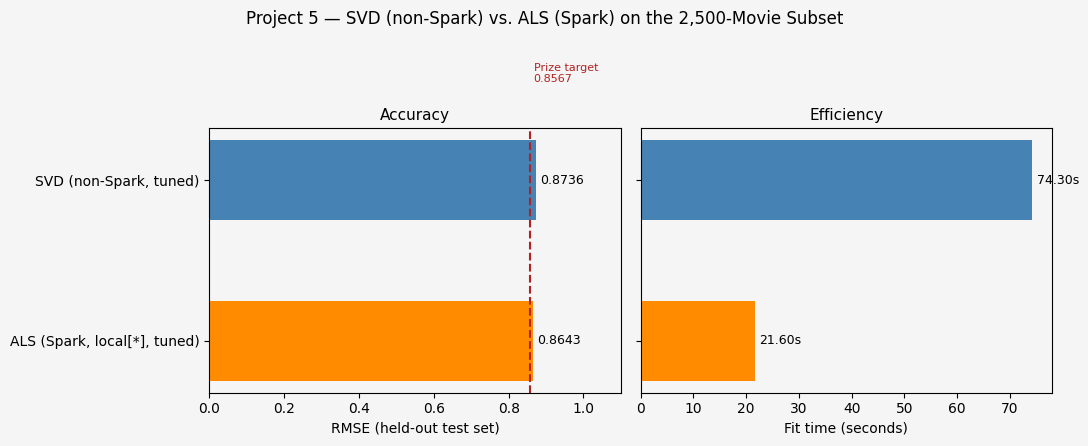

In [5]:
TARGET = 0.8567   # Netflix Prize winning RMSE, same reference line used since Project 3

comparison_summary = pd.DataFrame([
    {'label': 'SVD (non-Spark, tuned)', 'rmse': baseline_rmse, 'mae': baseline_mae, 'fit_seconds': baseline_fit_seconds},
    {'label': 'ALS (Spark, local[*], tuned)', 'rmse': als_rmse, 'mae': als_mae, 'fit_seconds': als_fit_seconds},
])
print(comparison_summary.to_string(index=False))

fig, (rmse_ax, timing_ax) = plt.subplots(1, 2, figsize=(11, 4.5))

# --- left panel: RMSE, with the Netflix Prize target line for continuity with earlier projects ---
bar_colors = ['steelblue', 'darkorange']
rmse_bars = rmse_ax.barh(comparison_summary['label'], comparison_summary['rmse'], color=bar_colors, height=0.5)
rmse_ax.axvline(TARGET, color='firebrick', linestyle='--', linewidth=1.5)
rmse_ax.text(TARGET + 0.01, -0.6, f'Prize target\n{TARGET}', color='firebrick', fontsize=8, va='bottom')
rmse_ax.bar_label(rmse_bars, labels=[f'{v:.4f}' for v in comparison_summary['rmse']], padding=3, fontsize=9)
rmse_ax.set_xlabel('RMSE (held-out test set)', fontsize=10)
rmse_ax.set_title('Accuracy', fontsize=11)
rmse_ax.set_xlim(0, max(1.1, comparison_summary['rmse'].max() + 0.2))
rmse_ax.invert_yaxis()

# --- right panel: wall-clock fit time, the efficiency half of the comparison ---
timing_bars = timing_ax.barh(comparison_summary['label'], comparison_summary['fit_seconds'], color=bar_colors, height=0.5)
timing_ax.bar_label(timing_bars, labels=[f'{v:.2f}s' for v in comparison_summary['fit_seconds']], padding=3, fontsize=9)
timing_ax.set_xlabel('Fit time (seconds)', fontsize=10)
timing_ax.set_title('Efficiency', fontsize=11)
timing_ax.set_yticklabels([])
timing_ax.invert_yaxis()

# --- shared styling, matching the whitesmoke/named-color convention used since Project 3 ---
fig.patch.set_facecolor('whitesmoke')
rmse_ax.set_facecolor('whitesmoke')
timing_ax.set_facecolor('whitesmoke')
fig.suptitle('Project 5 — SVD (non-Spark) vs. ALS (Spark) on the 2,500-Movie Subset', fontsize=12)
plt.tight_layout()
plt.savefig('p5_svd_vs_als_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Devil's Advocate: What This Comparison Does and Doesn't Prove

Once each model is tuned on its own terms on this subset, using the same shared train/test split, Section 5 shows a genuinely mixed result: ALS posts the better RMSE (0.8643 vs. 0.8736) and a faster fit time (21.60s vs. 74.30s), while SVD holds a slight edge on MAE (0.6761 vs. 0.6825). A mixed result deserves the same scrutiny as a clean win, not less, because it is easy to quietly cite whichever metric favors the point being made.

**This changes both the platform and the algorithm at once.** Adapting this recommender to Spark effectively means adopting ALS, since Spark's MLlib has no direct SGD-based SVD equivalent to `surprise`. So whichever model wins in Section 5, that result reflects a platform switch and an algorithm switch happening together -- it should not be read as "Spark won" or "Spark lost" on its own.

**The sweep grid itself is coarse.** Both models now search the same five-point regularization grid (`[0.01, 0.02, 0.05, 0.1, 0.2]`), which puts them on equal footing, but a finer or asymmetric grid could still turn up a better configuration for either solver that this coarse sweep misses. Five points is a reasonable amount of tuning effort for a course project, not a guarantee that either model is running at its true best.

**`local[*]` still is not real distribution.** Whichever model wins on wall-clock time here, that speed came from running on one machine's threads, not from spreading work across a genuine cluster. Winning a wall-clock race in local mode says nothing about whether multi-machine distribution -- the thing this project is actually asking about -- was necessary; it was never exercised at all.

**Silent data loss from `coldStartStrategy='drop'`.** Any user or movie that appears only in the test split and not in training gets dropped from evaluation rather than scored. Section 4's output quantifies this directly: 0 of 4,383,511 test rows were dropped in this run. That is expected at this scale, not a coincidence -- with roughly 8,800 ratings per movie on average and a 20-rating floor per user, the odds of any single movie or user having every one of its ratings land in the random 20% test split are vanishingly small. A sparser subset, a smaller one, or a genuine time-based or cold-start-focused holdout could still produce real drops, so the code guard is still the right default -- it simply never gets exercised at this scale, which is itself worth knowing rather than assuming.

**Precision/recall/coverage are computed only on held-out test items.** Section 7's ranking metrics rank movies within each user's test-set slice, not a full re-ranking of the entire catalog the way a production system would need to. With far more users than movies in this subset, catalog coverage is also structurally easy to push toward 100% regardless of recommendation quality, so it is a useful diagnostic, not strong proof of real-world diversity.

**Neither model is more explainable than the other.** Both SVD and ALS produce dense, uninterpretable latent factors -- there is no `factor 7 means romantic comedies` guarantee in either implementation, regardless of which one wins on RMSE or speed.

## 7. Good Metrics ≠ Good Recommender: Precision, Recall, and Coverage on ALS's Recommendations

RMSE and MAE describe how close predicted ratings are to actual ones — they say nothing about whether the ranked list of recommendations ALS would actually surface is useful. Following Project 3's approach, Precision@10 and Recall@10 (relevant = actual rating >= 4) and catalog coverage are computed directly on ALS's test-set predictions -- a useful offline diagnostic, though one limited to ranking within each user's held-out test items rather than the full catalog, and coverage in particular is easier to reach when a subset has far more users than movies, as this one does.

In [6]:
def precision_recall_at_k(predictions_df, k=10, threshold=4.0):
    """Relevant = actual rating >= threshold. Denominator is the number of items actually
    available to rank for a given user, matching the approach used in Project 3."""
    user_est_true = defaultdict(list)          # user_id -> list of (predicted, actual) rating pairs
    for _, row in predictions_df.iterrows():
        user_est_true[row['user_id']].append((row['prediction'], row['rating']))

    precisions, recalls = {}, {}
    for uid, ratings in user_est_true.items():
        ratings.sort(key=lambda x: x[0], reverse=True)                 # rank by predicted rating
        top_k = ratings[:k]
        n_rel = sum((true_r >= threshold) for (_, true_r) in ratings)              # relevant in full test set
        n_rel_in_top_k = sum((true_r >= threshold) for (_, true_r) in top_k)       # relevant in top-k
        denom = len(top_k)
        precisions[uid] = n_rel_in_top_k / denom if denom > 0 else 0
        recalls[uid] = n_rel_in_top_k / n_rel if n_rel != 0 else None

    valid_recalls = [r for r in recalls.values() if r is not None]
    return sum(precisions.values()) / len(precisions), sum(valid_recalls) / len(valid_recalls)

als_precision_10, als_recall_10 = precision_recall_at_k(als_predictions_pd, k=10, threshold=4.0)
als_f1_10 = 2 * als_precision_10 * als_recall_10 / (als_precision_10 + als_recall_10) if (als_precision_10 + als_recall_10) > 0 else 0  # harmonic mean

print(f'ALS Precision@10: {als_precision_10:.4f}   Recall@10: {als_recall_10:.4f}   F1@10: {als_f1_10:.4f}')

# Coverage: fraction of the 2,500-movie subset that appears in at least one user's top-10
top10_recommended_movies = set()                    # unique movies that show up in any user's top-10
predictions_by_user = als_predictions_pd.sort_values('prediction', ascending=False).groupby('user_id')  # ranked per user
for user_id, user_predictions in predictions_by_user:
    top10_recommended_movies.update(user_predictions['movie_id'].head(10))

catalog_coverage = len(top10_recommended_movies) / netflix_subset['movie_id'].nunique()
print(f'Catalog coverage (top-10 lists, test set): {catalog_coverage:.2%}  '
      f'({len(top10_recommended_movies)}/{netflix_subset["movie_id"].nunique()} movies)')

ALS Precision@10: 0.6834   Recall@10: 0.8039   F1@10: 0.7387
Catalog coverage (top-10 lists, test set): 99.96%  (2499/2500 movies)


## 8. Conclusion: At What Point Does Distributing This Recommender Become Necessary?

The assignment asks this directly, so the answer needs to be direct too. On this subset, once each model is tuned on its own terms using the same shared train/test split, ALS posts the better RMSE (0.8643 vs. 0.8736) and a faster fit time (21.60s vs. 74.30s), while SVD holds a slight edge on MAE (0.6761 vs. 0.6825) -- a genuinely mixed result, not a clean sweep for either model. ALS's 0.8643 is also the closest this project series has come to the Netflix Prize's own winning RMSE of 0.8567 -- within 0.0076, versus 0.9126 for Project 3's original SVD and 0.9186 for Project 2's IBCF, though that gain owes as much to this project's much larger 2,500-movie subset as it does to switching models. It is worth being precise about what this does and does not prove: this comparison changes both the platform (a single machine vs. Spark's `local[*]` mode) and the algorithm (`surprise`'s SGD-based SVD vs. Spark's alternating least squares) at the same time, since adapting to Spark for this kind of collaborative filtering effectively means adopting ALS -- Spark's MLlib offers no direct SGD-based SVD equivalent. So neither result reflects "Spark vs. no Spark" in isolation.

`local[*]` mode also never left one laptop, so ALS's large speed advantage here reflects a well-suited optimizer running multi-threaded on a single machine, not genuine multi-machine distribution. Distributing a computation across a real cluster only pays off once the cost of *not* distributing it outweighs the fixed overhead of spinning up a distributed session -- and at this subset's scale (2,500 movies, 21,917,552 ratings), a full five-point regularization sweep for both models still completed on a laptop in a few minutes, so that threshold has not been crossed yet.

That threshold becomes real, not hypothetical, at the scale this semester's final project targets: the full Netflix Prize corpus across all four `combined_data` files, roughly 100 million ratings from 480,000 users against 17,770 movies -- close to five times this subset's ratings count. The bottleneck there is not that a dense user-item matrix cannot fit in memory -- no practical recommender system materializes that dense matrix; both `surprise` and Spark work directly from the sparse ratings table. There is an early, if noisy, sign of where the real cost lies: going from the smaller 1,180-movie subset to this one, ratings grew about 5.6x (3.93 million to 21.9 million); SVD's fit time grew about 5.7x (13.08s to 74.30s) while ALS's grew about 4.9x (4.43s to 21.60s). ALS still scales somewhat better, but the gap is more modest than it looked in an earlier pass at this same comparison, and wall-clock fit times swing by 15-20% run to run on a single laptop even when the code is unchanged (SVD's own fit time alone has ranged from the low-70s to the high-90s across separate runs here) -- so this should be read as a soft signal pointing toward ALS's parallelization advantage, not a precise benchmark of it. That is the point where ALS's ability to solve each user's (or item's) least-squares system independently, in parallel, across a real multi-machine cluster -- not just multiple threads on one laptop -- becomes one of the more practical ways to fit and tune the model efficiently, not the only one. The honest answer here is that this recommender's data is not yet past that line, but the scaling pattern above is a preview of why the final project's full-scale run will need exactly this kind of distributed approach.

## 9. Summary

**Configuration:** SVD (n_factors=20, reg_all swept over [0.01, 0.02, 0.05, 0.1, 0.2], best at reg_all=0.02) vs. ALS (rank=20, regParam swept over the same grid, best at regParam=0.1), both fit on the same shared train/test split from the true top-2,500-most-rated-movie subset (258,283 users, 21,917,552 ratings, 96.61% sparsity).

**Key findings:**
- The result is genuinely mixed, not a clean win for either model: ALS posts the better RMSE (0.8643 vs. 0.8736) and a faster fit time (21.60s vs. 74.30s), while SVD holds a slight MAE edge (0.6761 vs. 0.6825). ALS's 0.8643 is the closest this project series has gotten to the Netflix Prize's 0.8567 winning RMSE, though the larger subset used here likely deserves as much credit for that as the model choice does.
- Both models are tuned on their own terms using an identical train/test split, not just the same ratio and seed applied independently, so this comparison is much more controlled than using separate random splits.
- This comparison changes both the platform and the algorithm at once -- adapting to Spark for this kind of collaborative filtering means adopting ALS, since Spark's MLlib has no direct SGD-based SVD equivalent -- so neither result should be read as "Spark itself" winning or losing.
- Comparing against the earlier, smaller subset (1,180 movies, 3.93 million ratings), SVD's fit time grew about 5.7x (13.08s to 74.30s) as ratings grew about 5.6x, while ALS's fit time grew about 4.9x (4.43s to 21.60s) -- ALS still scales a bit better, though the gap is modest and wall-clock fit times vary 15-20% run to run on this machine, so it's a soft signal rather than decisive proof.
- Precision@10 (0.6834), Recall@10 (0.8039), F1@10 (0.7387), and 99.96% catalog coverage (2,499/2,500 movies) on ALS's recommendations are useful offline diagnostics computed only against held-out test items, not a full-catalog production evaluation, and coverage this close to 100% is expected given how much larger the user count (258,283) is than the movie count (2,500).
- The honest answer to "when does Spark's distribution become necessary" is: not yet, at this subset's scale -- but the fit-time scaling pattern above previews exactly why it becomes necessary at the full ~100-million-row scale targeted by the final project, where repeated full passes and hyperparameter sweeps over sparse data (not a dense matrix that needs to fit in memory) make a real multi-machine cluster genuinely useful rather than optional.